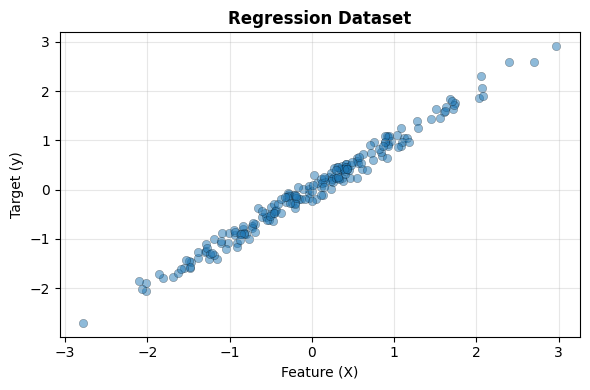

Linear Regression MSE: 0.0173


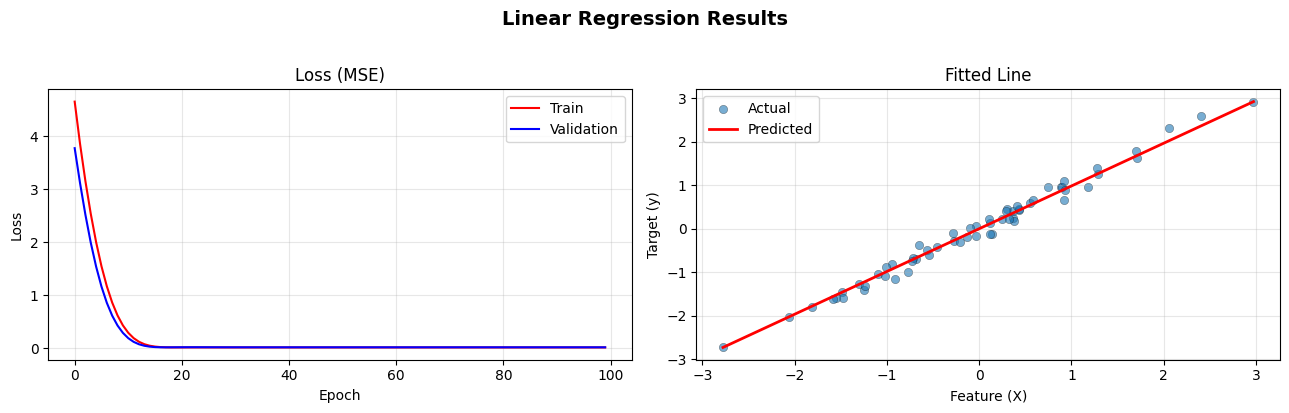

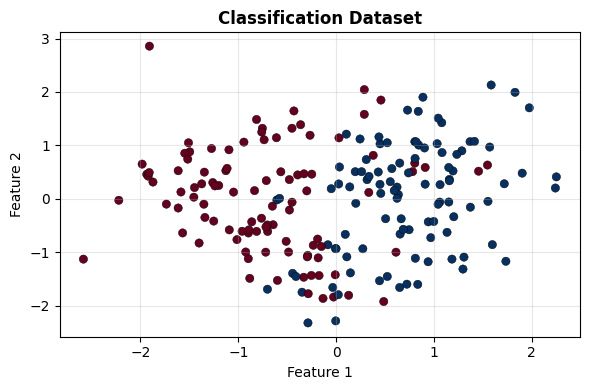

Logistic Regression Accuracy: 0.6000


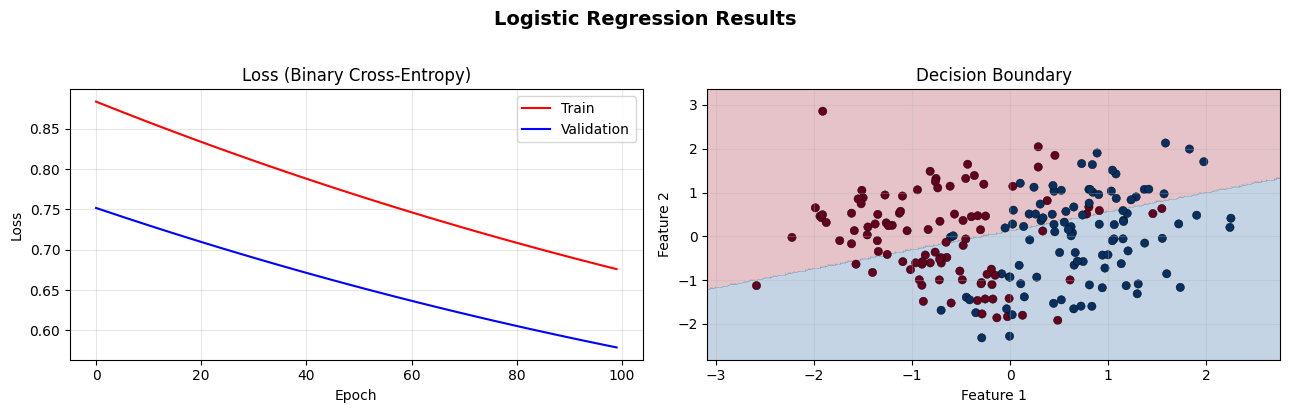

In [1]:
# ==============================
# Week 3 - Linear & Logistic Regression (Keras)
# ==============================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

tf.random.set_seed(42)
np.random.seed(42)

# ==============================
# 1. Linear Regression
# ==============================

# --- Data ---
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=10, random_state=42)
scaler_reg = StandardScaler()
X_reg = scaler_reg.fit_transform(X_reg)
y_reg = (y_reg - y_reg.mean()) / y_reg.std()   # scale target too

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)

# --- Visualize Data ---
plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg, alpha=0.5, edgecolors='k', linewidth=0.3)
plt.title('Regression Dataset', fontweight='bold')
plt.xlabel('Feature (X)'); plt.ylabel('Target (y)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# --- Model & Train ---
model = tf.keras.Sequential([tf.keras.layers.Dense(1)])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05), loss='mse')
history_reg = model.fit(X_train_r, y_train_r, epochs=100, validation_split=0.2, verbose=0)

# --- Results ---
y_pred_r = model.predict(X_test_r, verbose=0)
mse = mean_squared_error(y_test_r, y_pred_r)
print(f"Linear Regression MSE: {mse:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_reg.history['loss'], 'r-', label='Train')
ax1.plot(history_reg.history['val_loss'], 'b-', label='Validation')
ax1.set(title='Loss (MSE)', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.scatter(X_test_r, y_test_r, alpha=0.6, label='Actual', edgecolors='k', linewidth=0.3)
x_line = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
ax2.plot(x_line, model.predict(x_line, verbose=0), 'r-', linewidth=2, label='Predicted')
ax2.set(title='Fitted Line', xlabel='Feature (X)', ylabel='Target (y)')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('Linear Regression Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ==============================
# 2. Logistic Regression
# ==============================

# --- Data ---
X_clf, y_clf = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_classes=2, random_state=42)
scaler_clf = StandardScaler()
X_clf = scaler_clf.fit_transform(X_clf)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42)

# --- Visualize Data ---
plt.figure(figsize=(6, 4))
plt.scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap='RdBu', edgecolors='k', linewidth=0.3)
plt.title('Classification Dataset', fontweight='bold')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# --- Model & Train ---
model = tf.keras.Sequential([tf.keras.layers.Dense(1, activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_clf = model.fit(X_train_c, y_train_c, epochs=100, validation_split=0.2, verbose=0)

# --- Results ---
loss, acc = model.evaluate(X_test_c, y_test_c, verbose=0)
print(f"Logistic Regression Accuracy: {acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_clf.history['loss'], 'r-', label='Train')
ax1.plot(history_clf.history['val_loss'], 'b-', label='Validation')
ax1.set(title='Loss (Binary Cross-Entropy)', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Decision Boundary
xx, yy = np.meshgrid(np.linspace(X_clf[:,0].min()-0.5, X_clf[:,0].max()+0.5, 200),
                      np.linspace(X_clf[:,1].min()-0.5, X_clf[:,1].max()+0.5, 200))
Z = (model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0) > 0.5).astype(int).reshape(xx.shape)
ax2.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
ax2.scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap='RdBu', edgecolors='k', linewidth=0.3)
ax2.set(title='Decision Boundary', xlabel='Feature 1', ylabel='Feature 2')
ax2.grid(True, alpha=0.3)

fig.suptitle('Logistic Regression Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()